# Notebook 01: Data Loading & Exploration

## Purpose
This notebook loads the full CMU Enron email dataset (517,401 raw email files) from the maildir directory structure, parses them into a structured pandas DataFrame, cleans the date fields, and performs initial exploratory analysis.

## Objectives Addressed
- **Objective 1**: Collect and prepare the CMU Enron email dataset for analysis
- **Objective 8**: Visualise communication patterns over time

## Key Outputs
- Parsed DataFrame saved as `emails_raw.pkl` (516,359 emails after date filtering)
- Email volume timeline figure
- Top users by email count figure

In [1]:
import os
import email
import pandas as pd
from tqdm import tqdm
from pathlib import Path

MAILDIR = "../data/raw/maildir"

def parse_email(filepath):
    """Parse a single raw email file into a dictionary."""
    try:
        with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
            msg = email.message_from_file(f)
        return {
            'file_path': str(filepath),
            'user': filepath.split('/maildir/')[1].split('/')[0],
            'folder': '/'.join(filepath.split('/maildir/')[1].split('/')[1:-1]),
            'message_id': msg.get('Message-ID', ''),
            'date': msg.get('Date', ''),
            'from': msg.get('From', ''),
            'to': msg.get('To', ''),
            'cc': msg.get('Cc', ''),
            'bcc': msg.get('Bcc', ''),
            'subject': msg.get('Subject', ''),
            'body': msg.get_payload(decode=False) if isinstance(msg.get_payload(), str) else ''
        }
    except Exception as e:
        return None

# Collect all email file paths
email_paths = []
for root, dirs, files in os.walk(MAILDIR):
    for fname in files:
        if not fname.startswith('.'):
            email_paths.append(os.path.join(root, fname))

print(f"Found {len(email_paths):,} email files")

Found 517,401 email files


## 1.1 Email Parsing
The raw dataset is stored as individual text files in a directory structure organised by user and folder (inbox, sent, etc.). Each file contains standard email headers (From, To, Subject, Date) followed by the body text. We use Python's built-in `email` library to parse these into structured fields.

In [2]:
# Parse all emails (this takes 5-15 minutes)
records = []
for path in tqdm(email_paths, desc="Parsing emails"):
    result = parse_email(path)
    if result and result['body']:
        records.append(result)

df = pd.DataFrame(records)
print(f"Parsed {len(df):,} emails successfully")

Parsing emails: 100%|██████████| 517401/517401 [01:40<00:00, 5166.62it/s]


Parsed 517,401 emails successfully


## 1.2 Date Cleaning
Many raw date strings contain timezone abbreviations and non-standard formats. We use both `parsedate_to_datetime` and `dateutil.parser` as a fallback to maximise successful parsing. Emails outside the 1998-2002 range are filtered out as they fall outside the Enron operational period.

In [4]:
from email.utils import parsedate_to_datetime
from dateutil import parser as date_parser

def parse_date_safe(date_str):
    try:
        return parsedate_to_datetime(date_str)
    except:
        try:
            return date_parser.parse(date_str)
        except:
            return None

df['datetime'] = df['date'].apply(parse_date_safe)
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce', utc=True)
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.to_period('M')

# Filter to reasonable date range (Enron era: 1998-2002)
df = df[(df['year'] >= 1998) & (df['year'] <= 2002)]
print(f"Emails in 1998-2002 range: {len(df):,}")

/var/folders/f6/mm2rcp015fj73gp7jk4fbh4c0000gn/T/ipykernel_47114/2972633333.py:16: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['datetime'].dt.to_period('M')


Emails in 1998-2002 range: 516,359


## 1.3 Exploratory Analysis
Initial visualisations establish a baseline understanding of the dataset before any anomaly detection. We examine which users are most active and how email volume changes over time, particularly around the key crisis period of late 2001.

Matplotlib is building the font cache; this may take a moment.


Unique senders: 20298
Unique users (mailboxes): 150
Date range: 1998-01-04 17:46:00+00:00 to 2002-12-21 08:24:45+00:00


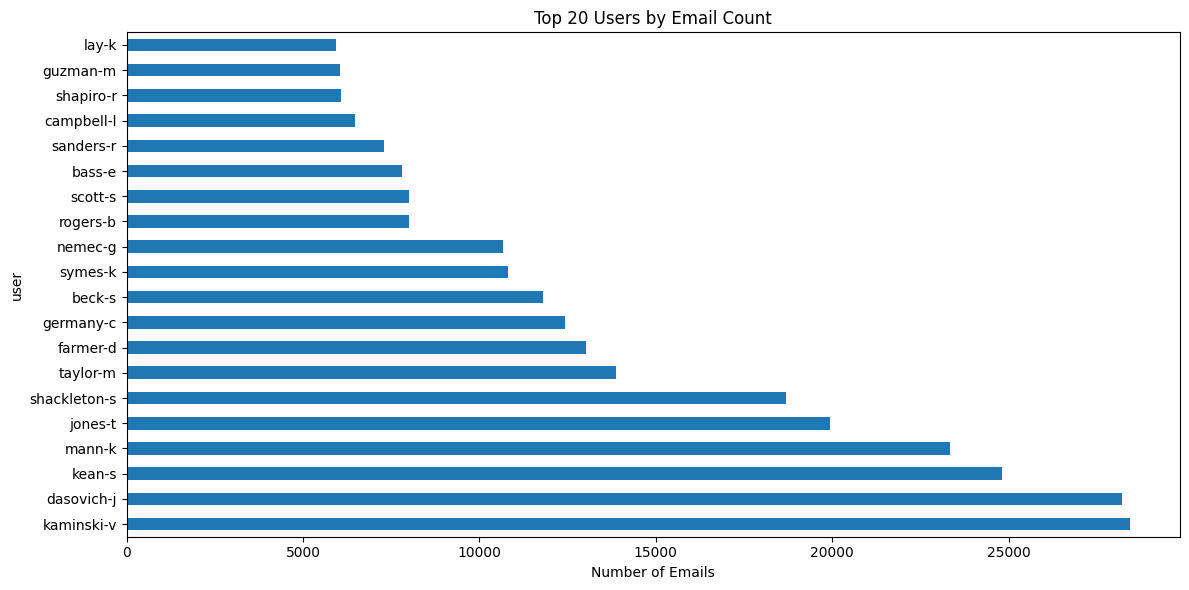

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Basic stats
print(f"Unique senders: {df['from'].nunique()}")
print(f"Unique users (mailboxes): {df['user'].nunique()}")
print(f"Date range: {df['datetime'].min()} to {df['datetime'].max()}")

# Emails per user (top 20)
top_users = df['user'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(12, 6))
top_users.plot(kind='barh', ax=ax)
ax.set_xlabel('Number of Emails')
ax.set_title('Top 20 Users by Email Count')
plt.tight_layout()
plt.savefig('../results/figures/top_users.png', dpi=150)
plt.show()

/var/folders/f6/mm2rcp015fj73gp7jk4fbh4c0000gn/T/ipykernel_47114/3407152441.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = df.groupby(df['datetime'].dt.to_period('M')).size()


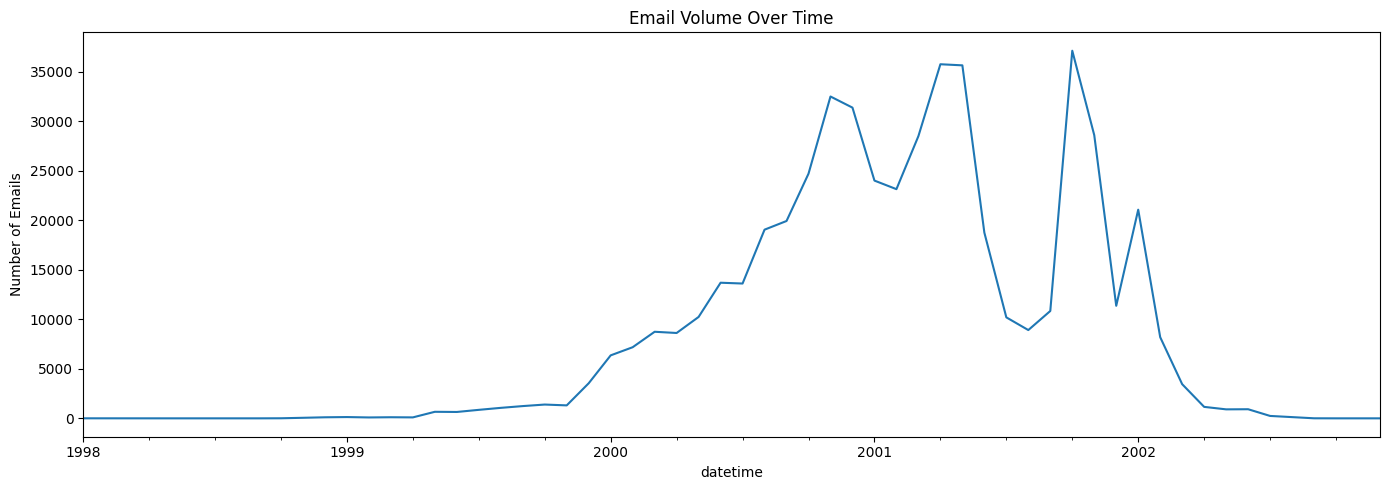

In [6]:
# Emails over time
monthly = df.groupby(df['datetime'].dt.to_period('M')).size()
fig, ax = plt.subplots(figsize=(14, 5))
monthly.plot(ax=ax)
ax.set_title('Email Volume Over Time')
ax.set_ylabel('Number of Emails')
plt.tight_layout()
plt.savefig('../results/figures/email_volume_timeline.png', dpi=150)
plt.show()

## 1.4 Save Processed Data
The parsed DataFrame is saved as a pickle file so subsequent notebooks can load it instantly without re-parsing the raw email files.

In [7]:
# Save so you don't have to re-parse every time
df.to_pickle('../data/processed/emails_raw.pkl')
print(f"Saved {len(df):,} emails to data/processed/emails_raw.pkl")

# Also save a smaller CSV for quick inspection
df.head(1000).to_csv('../data/processed/emails_sample.csv', index=False)

Saved 516,359 emails to data/processed/emails_raw.pkl
